In [1]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# plt.rcParams['figure.figsize'] = [16, 8]
 
A = imread('luna.jpg')
img = plt.imshow(A)
# X = np.mean(A, -1)
R = A[:, :, 0] # divisão da foto para espectro vermelho
G = A[:, :, 1] # divisão da foto para espectro verde
B = A[:, :, 2] # divisão da foto para espectro azul

U_red, S_red, V_red = np.linalg.svd(R)
U_green, S_green, V_green = np.linalg.svd(G)
U_blue, S_blue, V_blue = np.linalg.svd(B)


plt.axis('off')
plt.show()

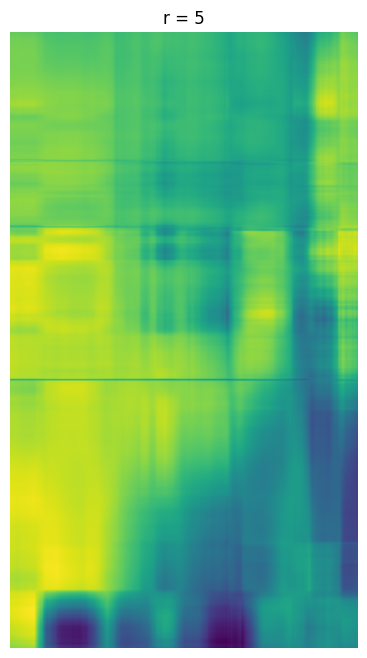

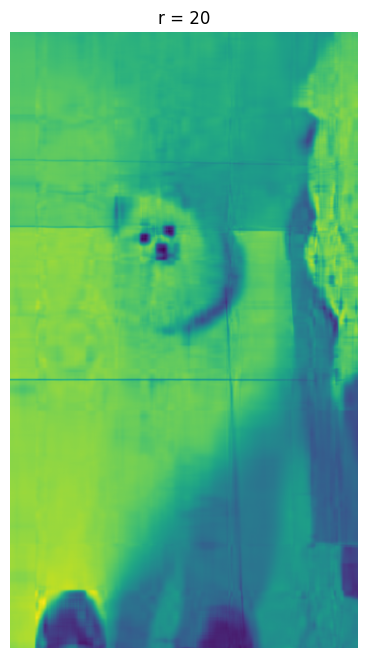

In [ ]:
for r in (10, 20, 100):
    compress_red=U_red[:, :r]@ np.diag(S_red[:r])@V_red[:r, :] #partial spectral decomposition - take first r number of singular values/vectors
    compress_red=compress_red.astype(int)
    
    compress_blue=U_blue[:, :r] @ np.diag(S_blue[:r])@V_blue[:r, :]
    compress_blue=compress_blue.astype(int)

    compress_green=U_green[:, :r]@ np.diag(S_green[:r])@V_green[:r, :]
    compress_green=compress_green.astype(int)

    compressed_array=np.stack((compress_red,  compress_green, compress_blue), axis=2)
    plt.figure(figsize=(10,10))
    plt.title(f'r ={r}')

    plt.imshow(compressed_array)